
# Logistic Regression — Classification Basics

### A complete beginner-friendly guide: Theory → Math → Hand Calculation → Code

---

Despite the name containing "regression," Logistic Regression is actually used for **classification**, not predicting continuous numbers. In this notebook, we build up the full understanding — starting from *why* Linear Regression fails for classification, all the way to solving one gradient-descent step **by hand**, before writing any code.

**What we'll cover:**
1. What is Classification?
2. Why can't we just use Linear Regression?
3. The Sigmoid Function
4. The Logistic Regression Equation & Decision Boundary
5. The Cost Function — Log Loss (Binary Cross-Entropy)
6. Gradient Descent for Logistic Regression
7. **Solving one training step by hand**, on paper, with real numbers
8. Evaluation Metrics (Accuracy, Precision, Recall, F1, Confusion Matrix)
9. Regularization in Logistic Regression
10. Multiclass Classification (Softmax)
11. Code — from a from-scratch implementation to an advanced version with regularization and multiclass support



## 1. What is Classification?

**Definition:** Classification is a supervised machine learning task where the goal is to predict which **category (class)** an input belongs to, rather than predicting a continuous number.

| Task | Type | Example Output |
|---|---|---|
| Predicting house price | Regression | ₹45,00,000 |
| Predicting if a tumor is malignant or benign | **Classification** | "Malignant" / "Benign" |
| Predicting if an email is spam | **Classification** | "Spam" / "Not Spam" |
| Predicting if a loan will default | **Classification** | "Default" / "No Default" |

**Binary Classification** means there are only **two** possible classes, usually labeled as $0$ and $1$. This is exactly what Logistic Regression is designed for (it can be extended to more classes too — we'll cover that later).



## 2. Why Can't We Just Use Linear Regression?

It's natural to ask: since we already know Linear Regression, why not just fit a straight line to predict 0 or 1?

There are two big problems:

**Problem 1: Predictions can go outside the range [0, 1]**

If we fit $\hat{y} = \beta_0 + \beta_1 x$ on data labeled 0 or 1, the line can easily predict values like $-0.3$ or $1.8$. But probabilities and class labels must lie between 0 and 1 — a prediction of $-0.3$ or $1.8$ makes no sense as "the chance of belonging to class 1."

**Problem 2: The relationship isn't actually linear**

Near the "boundary" between classes, small changes in $x$ should sharply change the predicted class. Far from the boundary, the prediction should stay confidently close to 0 or 1. A straight line can't produce this kind of *S-shaped* behavior — it just keeps increasing/decreasing linearly forever.

### The Fix: Squash the Output Into [0, 1]

Instead of directly outputting $\beta_0 + \beta_1 x$, Logistic Regression **first computes** this linear combination (exactly like linear regression), and then passes it through a special function that "squashes" any real number into the range $(0, 1)$. That function is the **Sigmoid Function**.



## 3. The Sigmoid Function

**Definition:** The Sigmoid (also called the **Logistic Function**) converts any real number (from $-\infty$ to $+\infty$) into a value between 0 and 1.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

**What each term means:**

| Symbol | Meaning |
|---|---|
| $z$ | Any real number (in our case, $z = \beta_0 + \beta_1 x$) |
| $e$ | Euler's number ($\approx 2.718$), the base of natural logarithm |
| $\sigma(z)$ (sigma) | The squashed output, always between 0 and 1 |

### Why This Works — Key Properties

- When $z \to +\infty$ (very large positive), $e^{-z} \to 0$, so $\sigma(z) \to 1$
- When $z \to -\infty$ (very large negative), $e^{-z} \to \infty$, so $\sigma(z) \to 0$
- When $z = 0$: $\sigma(0) = \frac{1}{1+e^0} = \frac{1}{1+1} = 0.5$ — exactly in the middle

This produces a smooth **S-shaped (sigmoid) curve** — flat near 0 and 1, and steep in the middle around $z=0$. This exactly matches the classification behavior we wanted: confident far from the boundary, uncertain (near 0.5) right at the boundary.

**Interpretation:** We treat $\sigma(z)$ as the **predicted probability** that the input belongs to class 1:

$$
P(y=1 \mid x) = \sigma(z)
$$



## 4. The Logistic Regression Equation & Decision Boundary

### Putting It Together

Step 1 — Compute the linear combination (just like linear regression):

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n
$$

Step 2 — Pass it through the sigmoid function:

$$
\hat{y} = \sigma(z) = \frac{1}{1+e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n)}}
$$

Here, $\hat{y}$ is interpreted as the **probability** that the input belongs to class 1.

### Making the Final Class Decision

Since $\hat{y}$ is a probability, we need a **threshold** to convert it into an actual class label. The typical default is 0.5:

$$
\text{Predicted Class} =
\begin{cases}
1 & \text{if } \hat{y} \geq 0.5 \\
0 & \text{if } \hat{y} < 0.5
\end{cases}
$$

### The Decision Boundary

The **decision boundary** is the line (or hyperplane, in higher dimensions) where the model is exactly 50-50 undecided, i.e., where $z = 0$:

$$
\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n = 0
$$

**Intuition:** Everything on one side of this boundary gets classified as class 1, and everything on the other side as class 0. Because $z$ is a *linear* combination of the inputs, this boundary is always a straight line (in 2D) or flat hyperplane (in higher dimensions) — this is why it's called "logistic **regression**" even though it's used for classification: it's still fundamentally built on a linear equation underneath the sigmoid.

### The "Log-Odds" View (Why It's Called *Logistic*)

There's another elegant way to see this. The **odds** of an event is $\frac{P(y=1)}{P(y=0)} = \frac{\hat{y}}{1-\hat{y}}$. Taking the natural log of the odds (called the **logit**) turns out to be exactly our linear equation:

$$
\ln\left(\frac{\hat{y}}{1-\hat{y}}\right) = \beta_0 + \beta_1 x
$$

This tells us: Logistic Regression assumes the **log-odds** of the outcome is a straight-line function of the inputs, even though the probability itself is an S-shaped curve.



## 5. The Cost Function — Log Loss (Binary Cross-Entropy)

### Why Not Reuse Mean Squared Error?

We could try using MSE like we did for Linear Regression, but here's the problem: because $\hat{y} = \sigma(z)$ is a nonlinear S-shaped function, plugging it into the MSE formula creates a cost function with **many bumps and dips (non-convex)**. Gradient Descent could easily get stuck in a "local dip" that isn't the true best answer.

### The Solution: Log Loss

Instead, Logistic Regression uses a cost function called **Log Loss** or **Binary Cross-Entropy**, designed specifically to be smooth and bowl-shaped (convex) for this problem, guaranteeing Gradient Descent can find the true minimum.

For a single data point:

$$
\text{Cost}(\hat{y}, y) =
\begin{cases}
-\log(\hat{y}) & \text{if } y = 1 \\
-\log(1-\hat{y}) & \text{if } y = 0
\end{cases}
$$

**Intuition behind this piecewise formula:**
- If the true label is $y=1$ and our model predicts $\hat{y}$ close to 1 (confident and correct) → $-\log(\hat{y}) \approx -\log(1) = 0$ → **very low cost**
- If the true label is $y=1$ but our model predicts $\hat{y}$ close to 0 (confidently wrong) → $-\log(\hat{y}) \approx -\log(0) \to \infty$ → **huge cost**

This is exactly the behavior we want: the model is punished severely for being confidently wrong, and rewarded for being confidently right.

### Combined Formula (for both cases at once)

Since $y$ is always either 0 or 1, we can write both cases as a single elegant formula (one term automatically vanishes depending on $y$):

$$
\text{Cost}(\hat{y}, y) = -\big[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\big]
$$

### Full Cost Function (Averaged Over All Data Points)

$$
J(\beta) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\Big]
$$

**Breaking the formula down:**

| Symbol | Meaning |
|---|---|
| $n$ | Number of training data points |
| $y_i$ | Actual class label (0 or 1) for point $i$ |
| $\hat{y}_i$ | Predicted probability ($\sigma(z_i)$) for point $i$ |
| $\log$ | Natural logarithm |

Our training goal is the same idea as before: **find the $\beta$ values that minimize $J(\beta)$.**



## 6. Gradient Descent for Logistic Regression

Unlike Linear Regression, Logistic Regression has **no direct closed-form solution** (no "Normal Equation" shortcut) — this is because of the nonlinear sigmoid function inside the cost. So Gradient Descent (or similar iterative optimizers) is the standard way to train it.

### The Beautiful Surprise

Despite the complex-looking cost function, when we take the derivative of $J(\beta)$ with respect to each parameter, the sigmoid's derivative cancels out neatly, leaving gradient formulas that look **almost identical** to Linear Regression's:

$$
\frac{\partial J}{\partial \beta_0} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)
$$

$$
\frac{\partial J}{\partial \beta_1} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i) \cdot x_i
$$

The only difference from Linear Regression's gradients is that $\hat{y}_i$ here means $\sigma(z_i)$ (a probability), instead of a raw linear prediction.

### The Update Rule

Exactly the same pattern as before:

$$
\beta_0 := \beta_0 - \alpha \frac{\partial J}{\partial \beta_0}
$$

$$
\beta_1 := \beta_1 - \alpha \frac{\partial J}{\partial \beta_1}
$$

Where $\alpha$ is again the **learning rate**, controlling step size.

### The Training Loop

1. Start with initial guesses for $\beta_0, \beta_1$ (often all zeros)
2. Compute $z$, then $\hat{y} = \sigma(z)$, for every data point
3. Compute the cost $J(\beta)$ (to track progress)
4. Compute the gradients
5. Update $\beta_0, \beta_1$ using the update rule
6. Repeat steps 2–5 for many iterations (epochs) until the cost stops decreasing meaningfully



## 7. Solving One Training Step *By Hand* — A Worked Example

Because Logistic Regression has no direct formula (unlike Linear Regression's Normal Equation), we can't jump straight to the final answer with algebra. Instead, let's do exactly what Gradient Descent does — **by hand, one full step** — so we deeply understand the mechanism. Then we'll let code run this same process for many more iterations to reach convergence.

### The Data

Predicting Pass (1) / Fail (0) based on Hours Studied:

| $x$ (Hours Studied) | $y$ (Pass=1 / Fail=0) |
|---|---|
| 1 | 0 |
| 2 | 0 |
| 3 | 1 |
| 4 | 1 |
| 5 | 1 |

We start with initial parameters $\beta_0 = 0$, $\beta_1 = 0$, and a learning rate $\alpha = 0.1$.

---

### Step 1: Compute $z_i = \beta_0 + \beta_1 x_i$ for every point

Since both $\beta_0=0$ and $\beta_1=0$:

$$
z_i = 0 + 0 \times x_i = 0 \quad \text{for every point}
$$

---

### Step 2: Apply the Sigmoid to get predicted probabilities $\hat{y}_i = \sigma(z_i)$

$$
\sigma(0) = \frac{1}{1+e^{0}} = \frac{1}{1+1} = 0.5
$$

So **every point** starts with a predicted probability of exactly $0.5$ — which makes sense, since with all-zero parameters the model has no information yet and is maximally unsure.

| $x_i$ | $y_i$ | $z_i$ | $\hat{y}_i=\sigma(z_i)$ |
|---|---|---|---|
| 1 | 0 | 0 | 0.5 |
| 2 | 0 | 0 | 0.5 |
| 3 | 1 | 0 | 0.5 |
| 4 | 1 | 0 | 0.5 |
| 5 | 1 | 0 | 0.5 |

---

### Step 3: Compute the Initial Cost $J(\beta)$

$$
J = -\frac{1}{5}\sum \big[y_i\log(0.5) + (1-y_i)\log(0.5)\big] = -\frac{1}{5}\sum \log(0.5) = -\log(0.5) = \ln 2 \approx 0.693
$$

(A useful fact worth remembering: **any binary classifier that is totally unsure and guesses 0.5 for everything always starts with a Log Loss of exactly $\ln 2 \approx 0.693$.**)

---

### Step 4: Compute the Errors ($\hat{y}_i - y_i$)

| $x_i$ | $y_i$ | $\hat{y}_i$ | $\hat{y}_i - y_i$ |
|---|---|---|---|
| 1 | 0 | 0.5 | $0.5-0=0.5$ |
| 2 | 0 | 0.5 | $0.5-0=0.5$ |
| 3 | 1 | 0.5 | $0.5-1=-0.5$ |
| 4 | 1 | 0.5 | $0.5-1=-0.5$ |
| 5 | 1 | 0.5 | $0.5-1=-0.5$ |

---

### Step 5: Compute the Gradients

**Gradient for $\beta_0$:**

$$
\frac{\partial J}{\partial \beta_0} = \frac{1}{5}\sum(\hat{y}_i-y_i) = \frac{0.5+0.5-0.5-0.5-0.5}{5} = \frac{-0.5}{5} = -0.1
$$

**Gradient for $\beta_1$:** first multiply each error by its $x_i$:

| $(\hat{y}_i-y_i)\times x_i$ |
|---|
| $0.5 \times 1 = 0.5$ |
| $0.5 \times 2 = 1.0$ |
| $-0.5 \times 3 = -1.5$ |
| $-0.5 \times 4 = -2.0$ |
| $-0.5 \times 5 = -2.5$ |

Sum $= 0.5+1.0-1.5-2.0-2.5 = -4.5$

$$
\frac{\partial J}{\partial \beta_1} = \frac{-4.5}{5} = -0.9
$$

---

### Step 6: Update the Parameters

$$
\beta_0 := \beta_0 - \alpha \frac{\partial J}{\partial \beta_0} = 0 - (0.1)(-0.1) = 0.01
$$

$$
\beta_1 := \beta_1 - \alpha \frac{\partial J}{\partial \beta_1} = 0 - (0.1)(-0.9) = 0.09
$$

---

### Result After One Hand-Computed Step

$$
\boxed{\beta_0 = 0.01, \quad \beta_1 = 0.09}
$$

Notice $\beta_1$ moved in the **positive** direction — this makes sense! Higher $x$ (more hours studied) is associated with $y=1$ (pass) in our data, so the model correctly starts learning a positive relationship after just one step.

This exact same process — compute $z$, apply sigmoid, compute cost, compute gradients, update — would now repeat for hundreds of iterations. Each time, $\beta_0$ and $\beta_1$ inch closer to values that best separate the two classes. In the Code section below, we'll let the computer repeat this loop and watch the cost fall exactly the way our hand calculation predicts it should.



## 8. Evaluating a Classification Model

Unlike regression, "how close was the number" doesn't apply here — we need metrics based on **correct vs incorrect class predictions**.

### The Confusion Matrix

A table comparing actual vs predicted classes:

| | Predicted: 0 | Predicted: 1 |
|---|---|---|
| **Actual: 0** | True Negative (TN) | False Positive (FP) |
| **Actual: 1** | False Negative (FN) | True Positive (TP) |

### Key Metrics

**Accuracy** — overall, what fraction of predictions were correct?

$$
\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
$$

**Precision** — of everything we predicted as class 1, how many were actually class 1? (Useful when False Positives are costly, e.g., flagging a legitimate email as spam)

$$
\text{Precision} = \frac{TP}{TP+FP}
$$

**Recall (Sensitivity)** — of everything that was actually class 1, how many did we correctly catch? (Useful when False Negatives are costly, e.g., missing a disease diagnosis)

$$
\text{Recall} = \frac{TP}{TP+FN}
$$

**F1 Score** — the harmonic mean of Precision and Recall, useful when you want a single balanced number:

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**Why not always just use Accuracy?** If 95% of emails are "not spam," a lazy model that always predicts "not spam" gets 95% accuracy while being completely useless. Precision, Recall, and F1 expose this kind of failure that accuracy alone can hide — especially with **imbalanced classes**.



## 9. Regularization in Logistic Regression

Just like Linear Regression, Logistic Regression can overfit — especially with many features — by learning extremely large $\beta$ values that fit training data (including its noise) too precisely.

We add the same style of penalty to the cost function:

**L2 (Ridge-style) Regularized Cost:**

$$
J(\beta) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\Big] + \lambda \sum_{j=1}^{p}\beta_j^2
$$

**L1 (Lasso-style) Regularized Cost:**

$$
J(\beta) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\Big] + \lambda \sum_{j=1}^{p}|\beta_j|
$$

The intuition is identical to Linear Regression: $\lambda$ controls how strongly we discourage large coefficients, L2 shrinks smoothly, and L1 can push coefficients exactly to zero (feature selection).

### The `C` Parameter (Important for scikit-learn!)

In scikit-learn's `LogisticRegression`, regularization strength is controlled by a parameter called `C`, which is the **inverse** of $\lambda$:

$$
C = \frac{1}{\lambda}
$$

**This means:**
- **Small `C`** → large $\lambda$ → **strong** regularization → simpler model, more shrinkage
- **Large `C`** → small $\lambda$ → **weak** regularization → model fits training data more closely (risk of overfitting)

This is a common source of confusion for beginners, so it's worth remembering: `C` and regularization strength move in **opposite** directions.



## 10. Beyond Two Classes — Multiclass Classification

What if we have more than 2 classes, e.g., classifying an image as "Cat," "Dog," or "Bird"? Logistic Regression extends in two common ways:

### One-vs-Rest (OvR)

Train one binary logistic regression classifier **per class**, where each one answers: *"Is it this class, or not?"* For 3 classes, that's 3 separate binary classifiers. At prediction time, we pick whichever classifier gives the highest probability.

### Softmax Regression (Multinomial Logistic Regression)

Instead of separate sigmoids, we generalize to a **Softmax function**, which converts a vector of raw scores $z_1, z_2, \dots, z_k$ (one per class) into a valid probability distribution across all $k$ classes at once:

$$
P(y=k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$

**Intuition:** This is a direct extension of the sigmoid — instead of squashing one number into $(0,1)$, softmax normalizes *several* numbers so that they are all positive and **sum to exactly 1**, letting us interpret them as probabilities across multiple classes simultaneously. The class with the highest softmax probability is chosen as the prediction.

**Note:** In `scikit-learn`, `LogisticRegression` automatically switches to Softmax (multinomial) behavior internally whenever it detects more than two classes in the target — you don't need to configure anything extra.



## 11. Code — From Scratch to Advanced

Now let's implement everything in code, building up in stages:

1. **Basic:** Implement one Gradient Descent step from scratch, exactly reproducing our hand calculation
2. **Full training loop from scratch:** Run many iterations, track the cost (error) reducing, and plot it
3. **Using `scikit-learn`:** Explore key parameters (`penalty`, `C`, `solver`, `max_iter`, `class_weight`)
4. **Advanced:** Regularization comparison (L1 vs L2, effect of `C`), full evaluation with confusion matrix / precision / recall / F1, ROC-AUC curve, and multiclass classification with Softmax


In [1]:

# ============================================================
# STAGE 1: Reproduce our HAND-CALCULATED single Gradient Descent step
# ============================================================
import numpy as np

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 0, 1, 1, 1], dtype=float)
n = len(x)

# Initial parameters (same as our hand example)
beta_0, beta_1 = 0.0, 0.0
alpha = 0.1

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Step 1 & 2: compute z and predicted probabilities
z = beta_0 + beta_1 * x
y_hat = sigmoid(z)
print(f"z values: {z}")
print(f"Predicted probabilities (y_hat): {y_hat}")

# Step 3: initial cost (Log Loss) -- should equal ln(2) = 0.693
cost = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
print(f"Initial Cost (Log Loss): {cost:.4f}  (expected ~0.6931, i.e. ln(2))")

# Step 4 & 5: errors and gradients
error = y_hat - y
d_beta_0 = np.mean(error)
d_beta_1 = np.mean(error * x)
print(f"Gradient d(beta_0): {d_beta_0}")
print(f"Gradient d(beta_1): {d_beta_1}")

# Step 6: update parameters
beta_0 = beta_0 - alpha * d_beta_0
beta_1 = beta_1 - alpha * d_beta_1
print(f"\\nAfter ONE step -> beta_0: {beta_0:.4f}, beta_1: {beta_1:.4f}")
print("Matches our hand calculation: beta_0 = 0.01, beta_1 = 0.09")


z values: [0. 0. 0. 0. 0.]
Predicted probabilities (y_hat): [0.5 0.5 0.5 0.5 0.5]
Initial Cost (Log Loss): 0.6931  (expected ~0.6931, i.e. ln(2))
Gradient d(beta_0): -0.1
Gradient d(beta_1): -0.9
\nAfter ONE step -> beta_0: 0.0100, beta_1: 0.0900
Matches our hand calculation: beta_0 = 0.01, beta_1 = 0.09


In [2]:

# ============================================================
# STAGE 2: Full Gradient Descent training loop FROM SCRATCH
# Tracking cost reduction over many iterations
# ============================================================
import numpy as np

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 0, 1, 1, 1], dtype=float)
n = len(x)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

beta_0, beta_1 = 0.0, 0.0
alpha = 0.1
epochs = 2000
cost_history = []

for epoch in range(epochs):
    z = beta_0 + beta_1 * x
    y_hat = sigmoid(z)

    # Log Loss cost (with a tiny epsilon to avoid log(0) errors)
    eps = 1e-9
    cost = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    cost_history.append(cost)

    error = y_hat - y
    d_beta_0 = np.mean(error)
    d_beta_1 = np.mean(error * x)

    beta_0 -= alpha * d_beta_0
    beta_1 -= alpha * d_beta_1

print(f"Final beta_0: {beta_0:.4f}")
print(f"Final beta_1: {beta_1:.4f}")
print(f"Final Cost: {cost_history[-1]:.4f}")

# Final predictions and class labels (threshold = 0.5)
final_probs = sigmoid(beta_0 + beta_1 * x)
final_classes = (final_probs >= 0.5).astype(int)
print(f"\\nFinal predicted probabilities: {np.round(final_probs, 3)}")
print(f"Final predicted classes:       {final_classes}")
print(f"Actual classes:                {y.astype(int)}")


Final beta_0: -7.2000
Final beta_1: 2.9760
Final Cost: 0.0880
\nFinal predicted probabilities: [0.014 0.223 0.849 0.991 1.   ]
Final predicted classes:       [0 0 1 1 1]
Actual classes:                [0 0 1 1 1]


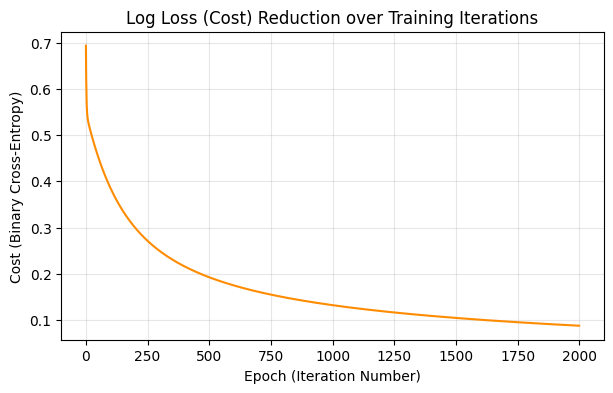

In [3]:

# ------------------------------------------------------------
# Visualizing the cost reducing over training iterations
# ------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(cost_history, color="darkorange")
plt.title("Log Loss (Cost) Reduction over Training Iterations")
plt.xlabel("Epoch (Iteration Number)")
plt.ylabel("Cost (Binary Cross-Entropy)")
plt.grid(alpha=0.3)
plt.show()


In [4]:

# ============================================================
# STAGE 3: Using scikit-learn's LogisticRegression
# Exploring different available parameters
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([0, 0, 1, 1, 1])

# --- Default model ---
model = LogisticRegression()
model.fit(X, y)
print("Default model:")
print(f"  Intercept (beta_0): {model.intercept_[0]:.4f}")
print(f"  Coefficient (beta_1): {model.coef_[0][0]:.4f}")
print(f"  Predicted probabilities: {model.predict_proba(X)[:, 1]}")
print(f"  Accuracy: {accuracy_score(y, model.predict(X)):.2f}")

# --- Parameter: penalty + C (regularization type and strength) ---
# penalty='l2' (default), C controls strength (small C = strong regularization)
model_strong_reg = LogisticRegression(penalty='l2', C=0.01)
model_strong_reg.fit(X, y)
print("\\nStrong regularization (C=0.01): coefficient shrinks towards 0")
print(f"  Coefficient: {model_strong_reg.coef_[0][0]:.4f}")

model_weak_reg = LogisticRegression(penalty='l2', C=100)
model_weak_reg.fit(X, y)
print("Weak regularization (C=100): coefficient allowed to grow larger")
print(f"  Coefficient: {model_weak_reg.coef_[0][0]:.4f}")

# --- Parameter: solver (optimization algorithm used internally) ---
model_solver = LogisticRegression(solver='liblinear')
model_solver.fit(X, y)
print(f"\\nModel with solver='liblinear': coefficient = {model_solver.coef_[0][0]:.4f}")

# --- Parameter: class_weight (useful for imbalanced datasets) ---
model_balanced = LogisticRegression(class_weight='balanced')
model_balanced.fit(X, y)
print(f"Model with class_weight='balanced': coefficient = {model_balanced.coef_[0][0]:.4f}")

# --- Parameter: max_iter (maximum optimizer iterations before stopping) ---
model_maxiter = LogisticRegression(max_iter=50)
model_maxiter.fit(X, y)
print(f"Model with max_iter=50: coefficient = {model_maxiter.coef_[0][0]:.4f}")


Default model:
  Intercept (beta_0): -2.5353
  Coefficient (beta_1): 1.0474
  Predicted probabilities: [0.1842387  0.39163002 0.64724664 0.83948245 0.93713314]
  Accuracy: 1.00
\nStrong regularization (C=0.01): coefficient shrinks towards 0
  Coefficient: 0.0293
Weak regularization (C=100): coefficient allowed to grow larger
  Coefficient: 5.6520
\nModel with solver='liblinear': coefficient = 0.4922
Model with class_weight='balanced': coefficient = 1.0606
Model with max_iter=50: coefficient = 1.0474


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [5]:

# ============================================================
# STAGE 4: ADVANCED -- Full evaluation + Regularization comparison
# + ROC-AUC curve using a larger, more realistic dataset
# ============================================================
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt

# Create a realistic binary classification dataset
X, y = make_classification(
    n_samples=500, n_features=10, n_informative=5,
    n_redundant=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Compare L1 vs L2 regularization ---
configs = {
    "L2, C=1.0 (default)": LogisticRegression(penalty='l2', C=1.0),
    "L2, C=0.01 (strong reg)": LogisticRegression(penalty='l2', C=0.01),
    "L1, C=1.0 (liblinear)": LogisticRegression(penalty='l1', C=1.0, solver='liblinear'),
}

print(f"{'Model':<28}{'Accuracy':>10}{'Precision':>11}{'Recall':>9}{'F1':>8}")
print("-" * 66)

for name, mdl in configs.items():
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"{name:<28}{acc:>10.3f}{prec:>11.3f}{rec:>9.3f}{f1:>8.3f}")

# --- Detailed evaluation for the default model ---
best_model = configs["L2, C=1.0 (default)"]
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
print(f"\\nConfusion Matrix (default L2 model):\\n{cm}")

auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc:.4f}")


Model                         Accuracy  Precision   Recall      F1
------------------------------------------------------------------
L2, C=1.0 (default)              0.820      0.881    0.740   0.804
L2, C=0.01 (strong reg)          0.720      0.789    0.600   0.682
L1, C=1.0 (liblinear)            0.820      0.881    0.740   0.804
\nConfusion Matrix (default L2 model):\n[[45  5]
 [13 37]]
ROC-AUC Score: 0.9124


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

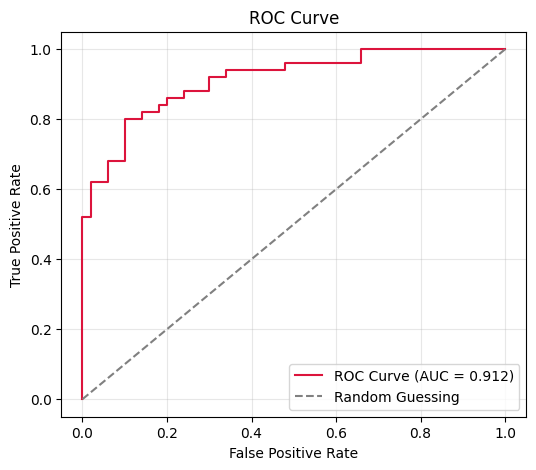

In [6]:

# ------------------------------------------------------------
# Plotting the ROC Curve
# (Shows the trade-off between True Positive Rate and False Positive Rate
#  at every possible decision threshold, not just 0.5)
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="crimson", label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [7]:

# ------------------------------------------------------------
# Multiclass Logistic Regression using Softmax
# (scikit-learn automatically uses Softmax/multinomial internally
#  whenever there are more than 2 classes -- no extra parameter needed
#  in recent versions of the library)
# ------------------------------------------------------------
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# The classic Iris dataset: 3 flower species, 4 features
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

softmax_model = LogisticRegression(max_iter=200)
softmax_model.fit(X_train, y_train)

y_pred = softmax_model.predict(X_test)
print(f"Multiclass Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\\nOne set of coefficients is learned PER CLASS (Softmax generalizes sigmoid):")
print(f"Coefficient matrix shape: {softmax_model.coef_.shape}  (3 classes x 4 features)")

print("\\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Multiclass Accuracy: 1.0000
\nOne set of coefficients is learned PER CLASS (Softmax generalizes sigmoid):
Coefficient matrix shape: (3, 4)  (3 classes x 4 features)
\nFull classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30




---
## Wrap-Up: What We Learned

- Classification predicts discrete categories; Logistic Regression handles this by squashing a linear equation through the **Sigmoid function** into a probability between 0 and 1.
- The **decision boundary** is where the model is 50/50 unsure ($z=0$); everything on either side is classified accordingly.
- We use **Log Loss (Binary Cross-Entropy)** instead of MSE because it stays smooth (convex) and appropriately punishes confident wrong predictions.
- There is **no closed-form Normal Equation** for Logistic Regression — training always relies on iterative optimization like Gradient Descent, which we solved one full step of **by hand**.
- **Accuracy, Precision, Recall, and F1** each tell a different part of the story about classifier performance, especially important with imbalanced classes.
- **Regularization** (L1/L2, controlled via the `C` parameter in scikit-learn — remember, `C` is the *inverse* of regularization strength) helps prevent overfitting.
- **Softmax Regression** generalizes Logistic Regression to handle more than two classes at once.
